In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn

## **Project Title: Phishing Website Detection System**
###Course: CS-455-Machine Learning-D (GIFT University)
###Description: Comprehensive pipeline comparing LinearSVC (ML) and Multi-Layer Perceptron (DL) for malicious/phishing URL classification using TF-IDF text features.


In [2]:
# Import tools for handling data and text patterns
import pandas as pd
import numpy as np
import re
import joblib

# Import tools for machine learning and split data
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Import ML and DL models
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

# Import tools for scores and plots
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Online URL of Kaggle Phishing Dataset
online_url = "https://raw.githubusercontent.com/cyberholics/Malicious-URL-detector/main/phishing_site_urls.csv"

print("Downloading dataset from online link")

try:
    full_data = pd.read_csv(online_url)
    print("Dataset loaded successfully!")

    sample_size = min(80000, len(full_data))
    good_data = full_data[full_data['Label'] == 'good'].sample(n=int(sample_size * 0.7), random_state=42)
    bad_data = full_data[full_data['Label'] == 'bad'].sample(n=int(sample_size * 0.3), random_state=42)

    data = pd.concat([good_data, bad_data]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Sampling Done: Using {len(data)} rows for high-accuracy training.")

except Exception as error:
    print(f"Download failed: {error}. Using fallback data.")
    mock_dict = {'URL': ['google.com', 'secure-login.com']*2500, 'Label': ['good', 'bad']*2500}
    data = pd.DataFrame(mock_dict)

data['Target'] = data['Label'].map({'good': 0, 'bad': 1})

Dataset loaded successfully!
Sampling Done: Using 80000 rows for high-accuracy training.


In [4]:
# Feature Extraction
def clean_url(url_text):
    words = re.split(r'[/-_.\?=\s]', url_text)
    return [w for w in words if len(w) > 0]

# Setup TF-IDF with 20,000 text features for deep learning
encoder = TfidfVectorizer(tokenizer=clean_url, max_features=20000)

print("Converting text URLs to numbers...")
X_features = encoder.fit_transform(data['URL'])
y_labels = data['Target'].values
print("Features conversion completed successfully!")

Converting text URLs to numbers...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Features conversion completed successfully!


In [5]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_labels,
    test_size=0.20,
    random_state=42,
    stratify=y_labels
)
print(f"Training items size: {X_train.shape[0]}")
print(f"Testing items size: {X_test.shape[0]}")

Training items size: 64000
Testing items size: 16000


In [6]:
# Create and train the Machine Learning LinearSVC model
ml_model = LinearSVC(C=1.0, random_state=42, max_iter=1000)
print("Training LinearSVC (ML Model)...")
ml_model.fit(X_train, y_train)

# Make predictions and calculate performance scores
ml_preds = ml_model.predict(X_test)
ml_acc = accuracy_score(y_test, ml_preds)
ml_prec = precision_score(y_test, ml_preds)
ml_rec = recall_score(y_test, ml_preds)
ml_cm = confusion_matrix(y_test, ml_preds)

print("\n--- Machine Learning (LinearSVC) Report ---")
print(classification_report(y_test, ml_preds, target_names=['Safe', 'Phishing']))

Training LinearSVC (ML Model)...

--- Machine Learning (LinearSVC) Report ---
              precision    recall  f1-score   support

        Safe       0.95      0.98      0.97     11200
    Phishing       0.95      0.89      0.92      4800

    accuracy                           0.95     16000
   macro avg       0.95      0.94      0.94     16000
weighted avg       0.95      0.95      0.95     16000



In [7]:
# Create and train the Deep Learning Multi-Layer Perceptron
dl_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=30, random_state=42)
print("Training MLP Neural Network (DL Model)...")
dl_model.fit(X_train, y_train)

# Make predictions and calculate performance scores
dl_preds = dl_model.predict(X_test)
dl_acc = accuracy_score(y_test, dl_preds)
dl_prec = precision_score(y_test, dl_preds)
dl_rec = recall_score(y_test, dl_preds)
dl_cm = confusion_matrix(y_test, dl_preds)

print("\n--- Deep Learning (MLP/ANN) Report ---")
print(classification_report(y_test, dl_preds, target_names=['Safe', 'Phishing']))

Training MLP Neural Network (DL Model)...

--- Deep Learning (MLP/ANN) Report ---
              precision    recall  f1-score   support

        Safe       0.96      0.97      0.97     11200
    Phishing       0.93      0.91      0.92      4800

    accuracy                           0.95     16000
   macro avg       0.95      0.94      0.94     16000
weighted avg       0.95      0.95      0.95     16000



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


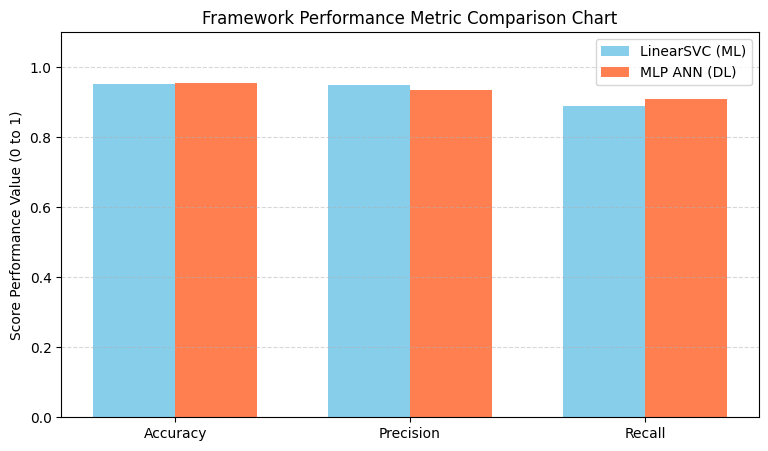

In [8]:
# Set up data bars for metrics
metrics_list = ['Accuracy', 'Precision', 'Recall']
ml_scores = [ml_acc, ml_prec, ml_rec]
dl_scores = [dl_acc, dl_prec, dl_rec]

x_indexes = np.arange(len(metrics_list))
bar_width = 0.35

# Plot size configuration
plt.figure(figsize=(9, 5))

# Draw the side-by-side bars
plt.bar(x_indexes - bar_width/2, ml_scores, width=bar_width, label='LinearSVC (ML)', color='skyblue')
plt.bar(x_indexes + bar_width/2, dl_scores, width=bar_width, label='MLP ANN (DL)', color='coral')

# Add graph details and titles
plt.xticks(x_indexes, metrics_list)
plt.ylabel('Score Performance Value (0 to 1)')
plt.title('Framework Performance Metric Comparison Chart')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show comparison plot
plt.show()

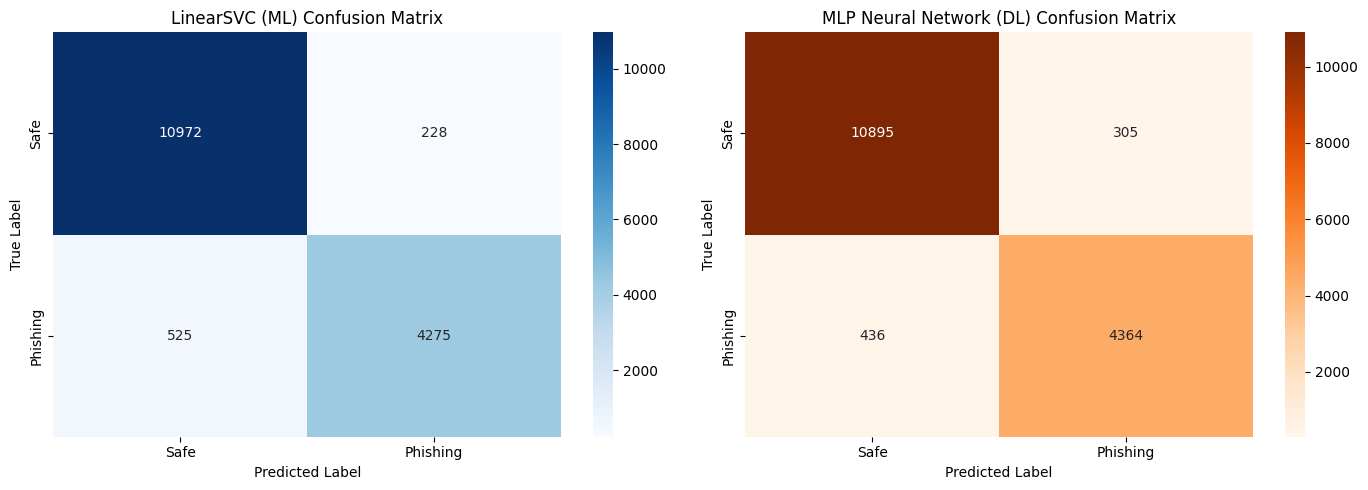

In [9]:
# Create 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap plot for ML model on the left
sns.heatmap(ml_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
axes[0].set_title('LinearSVC (ML) Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Heatmap plot for DL model on the right
sns.heatmap(dl_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
axes[1].set_title('MLP Neural Network (DL) Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Clean layout display
plt.tight_layout()
plt.show()

In [15]:
# Saved the trained model
joblib.dump(dl_model, 'phishing_dl_model.pkl')
joblib.dump(encoder, 'tfidf_encoder.pkl')
print("Models saved successfully!")

# Download the files
from google.colab import files
files.download('phishing_dl_model.pkl')
files.download('tfidf_encoder.pkl')

Models saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>